### 套索回归【alpha大小对结果影响】

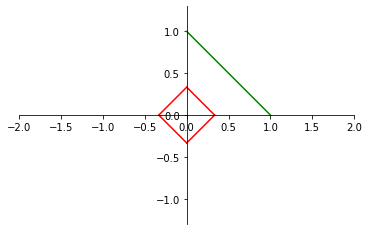

In [5]:
import matplotlib.pyplot as plt
import numpy as np
# α 的值是：1 只绘制第一象限
# 1 = x + y # w1 + w2
# y = 1 -x
f = lambda x : 1- x
x = np.linspace(0,1,100)
plt.axis('equal')
plt.plot(x, f(x), color = 'green')

# α 的值是：3
# 1 = 3 * x + 3 * y
# y = 1/3 -x
f2 = lambda x : 1/3 - x 
x2 = np.linspace(0,1/3,100)
plt.plot(x2, f2(x2),color = 'red')

# 1 = -3 * x + 3 * y
# y = 1/3 + x
f2 = lambda x : 1/3 + x 
x2 = np.linspace(-1/3,0,100)
plt.plot(x2,f2(x2),color = 'red')

# 1 = -3 * x - 3 * y
# y = -1/3 - x
f2 = lambda x : -1/3 - x 
x2 = np.linspace(-1/3,0,100)
plt.plot(x2,f2(x2),color = 'red')

# 1 = 3 * x - 3 * y
# y = -1/3 + x
f2 = lambda x : -1/3 + x 
x2 = np.linspace(0,1/3,100)
plt.plot(x2,f2(x2),color = 'red')

# 一些列设置
plt.xlim(-2,2)
plt.ylim(-2,2)
ax = plt.gca()
ax.spines['right'].set_color('None')  # 将图片的右框隐藏
ax.spines['top'].set_color('None')  # 将图片的上边框隐藏
ax.spines['bottom'].set_position(('data', 0)) # x轴出现在y轴的-1 位置
ax.spines['left'].set_position(('data', 0))

### Lasso回归公式

<font size = 18>$\min_{w} { \frac{1}{2n_{\text{samples}}} ||X w - y||_2 ^ 2 + \alpha ||w||_1}$</font>

### 岭回归公式

<font size = 18>$\min_{w} || X w - y||_2^2 + \alpha ||w||_2^2$</font>

### 代码演示Lasso套索回归使用

In [6]:
import numpy as np
from sklearn.linear_model import Lasso
from sklearn.linear_model import SGDRegressor

# 1、创建数据集X，y
X = 2*np.random.rand(100, 20)
w = np.random.randn(20,1) # 随机生成的系数，正态分布
b = np.random.randint(1,10,size = 1)
y = X.dot(w) + b + np.random.randn(100, 1)

print('原始方程的斜率：',w.ravel())
print('原始方程的截距：',b)

原始方程的斜率： [ 0.13794663  0.23957743 -0.99274923  0.24241383 -1.47215288 -0.88943009
 -0.59238961 -0.98397569  1.67915349  0.36002765 -0.19679724 -0.27150367
 -1.35394621 -0.83744517  0.95776869  2.42418618 -0.66472004  1.50679917
 -0.47460331 -0.58130382]
原始方程的截距： [7]


In [28]:
lasso = Lasso(alpha= 0.2) # alpha = 0相当于普通的线性回归
lasso.fit(X, y)
print('套索回归求解的斜率：',lasso.coef_)
print('套索回归求解的截距：',lasso.intercept_)

套索回归求解的斜率： [-0.          0.         -0.33191851  0.         -0.64616286 -0.
 -0.         -0.15776729  0.66068171  0.          0.         -0.18483571
 -0.40445626 -0.          0.2193078   1.61690457 -0.          1.36484553
 -0.         -0.        ]
套索回归求解的截距： [2.86916672]


In [26]:
# 线性回归梯度下降方法
# 随机梯度下降
from sklearn.linear_model import SGDRegressor
sgd = SGDRegressor(penalty='l1',alpha=0,eta0=0.05,max_iter=10000,learning_rate = 'constant')
sgd.fit(X, y.reshape(-1,))
print('随机梯度下降求解的斜率是：',sgd.coef_)
print('随机梯度下降求解的截距是：',sgd.intercept_)

随机梯度下降求解的斜率是： [-0.11084411  0.26094141 -0.74258832 -0.00319349 -0.86167771 -0.57235416
 -0.1022159  -0.53920635  1.13370644  0.37113579  0.54029559 -0.79502534
 -1.53340444 -0.73713792  1.07948316  2.77515305 -0.64862328  2.46767088
 -0.34429178 -0.49144274]
随机梯度下降求解的截距是： [4.38521713]


In [29]:
from sklearn.linear_model import LinearRegression # 正规方程，进行的求解
# 和梯度下降，完全不同的方式

### Ridge岭回归代码演示使用

In [30]:
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.linear_model import SGDRegressor

# 1、创建数据集X，y
X = 2*np.random.rand(100, 5)
w = np.random.randint(1,10,size = (5,1))
b = np.random.randint(1,10,size = 1)
y = X.dot(w) + b + np.random.randn(100, 1)

print('原始方程的斜率：',w.ravel())
print('原始方程的截距：',b)

原始方程的斜率： [3 2 8 9 6]
原始方程的截距： [4]


In [36]:
ridge = Ridge(alpha= 1, solver='sag')
ridge.fit(X, y)
print('岭回归求解的斜率：',ridge.coef_)
print('岭回归求解的截距：',ridge.intercept_)

岭回归求解的斜率： [[2.73706337 2.11099327 7.93240874 8.56370149 5.78573256]]
岭回归求解的截距： [4.85223789]


In [40]:
# 线性回归梯度下降方法
sgd = SGDRegressor(penalty='l2',alpha=0.0001,eta0=0.1)
sgd.fit(X, y.reshape(-1,))
print('随机梯度下降求解的斜率是：',sgd.coef_)
print('随机梯度下降求解的截距是：',sgd.intercept_)

随机梯度下降求解的斜率是： [2.81930586 2.16142465 8.12314854 8.86573726 5.91259024]
随机梯度下降求解的截距是： [4.3377837]


In [35]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X,y)
print('正规方程系数：',model.coef_)
print('正规方程截距：',model.intercept_)

正规方程系数： [[2.8392278  2.22628632 8.19917977 8.90746811 5.96564072]]
正规方程截距： [3.8278373]


### 弹性网络代码演示

In [41]:
import numpy as np
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import SGDRegressor

# 1、创建数据集X，y
X = 2*np.random.rand(100, 20)
w = np.random.randn(20,1)
b = np.random.randint(1,10,size = 1)
y = X.dot(w) + b + np.random.randn(100, 1)

print('原始方程的斜率：',w.ravel())
print('原始方程的截距：',b)

原始方程的斜率： [-0.68223921 -0.1395452   0.96172851 -0.04524133  0.60208331  0.35317963
  0.84714583  1.5845999  -0.79235874  1.71979183 -0.58605772  1.68296856
 -0.09634123  0.05183562 -0.36303392 -0.23157244 -0.18305657 -1.04403721
 -0.10958441 -0.98204261]
原始方程的截距： [8]


In [43]:
model = ElasticNet(alpha= 1, l1_ratio = 0.1)
model.fit(X, y)
print('弹性网络回归求解的斜率：',model.coef_)
print('弹性网络回归求解的截距：',model.intercept_)

弹性网络回归求解的斜率： [-0.14691901 -0.02668438  0.0627903  -0.          0.22422384  0.00994381
  0.25970885  0.27985127 -0.13857366  0.45811661 -0.06211301  0.41510316
  0.          0.04477934 -0.01611306 -0.08189909  0.         -0.33559505
  0.         -0.29064426]
弹性网络回归求解的截距： [9.72034564]


In [51]:
# 线性回归梯度下降方法
sgd = SGDRegressor(penalty='elasticnet',alpha=0.01, l1_ratio=0.5)
sgd.fit(X, y.reshape(-1,))
print('随机梯度下降求解的斜率是：',sgd.coef_)
print('随机梯度下降求解的截距是：',sgd.intercept_)

随机梯度下降求解的斜率是： [-0.41972285  0.          0.96492537  0.38112827  1.08842783  0.52352029
  1.21602763  1.75996509 -0.50252215  2.09171303  0.23622318  1.68374872
  0.39090882  0.65018206  0.          0.02487902  0.2005906  -0.75503387
  0.31155062 -0.69757873]
随机梯度下降求解的截距是： [1.2616688]


### 多项式实战

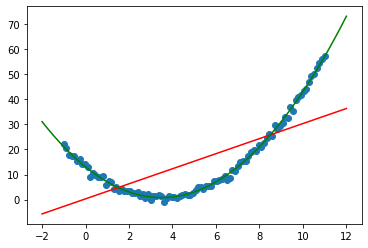

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression # 正规方程，没有进行梯度下降

# 1、创建数据，并进行可视化
X = np.linspace(-1,11,num = 100)
y = (X - 5)**2 + 3*X -12 + np.random.randn(100)
X = X.reshape(-1,1)
plt.scatter(X,y)

# 2、创建预测数据
X_test = np.linspace(-2,12,num = 200).reshape(-1,1)

# 3、不进行升维 + 正规方程线性回归
model_1 = LinearRegression()
model_1.fit(X,y)
y_test_1 = model_1.predict(X_test)
plt.plot(X_test,y_test_1,color = 'red')

# 4、多项式升维 + 正规方程线性回归
# 画龙点睛之步
X = np.concatenate([X,X**2],axis = 1) # 升维，特征变多，多了一列，平方
model_2 = LinearRegression()
model_2.fit(X,y)
# 5、测试数据处理，并预测
X_test = np.concatenate([X_test,X_test**2],axis = 1)
y_test_2 = model_2.predict(X_test) #预测

# 6、数据可视化，切片操作
plt.plot(X_test[:,0],y_test_2,color = 'green')

### 多项式实战【2.0】

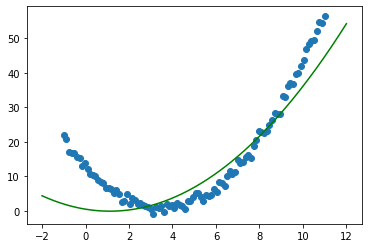

In [78]:
import numpy as np
import matplotlib.pyplot as plt
# PolynomialFeatures 多项式特征
from sklearn.preprocessing import PolynomialFeatures,StandardScaler # 标准化
from sklearn.linear_model import SGDRegressor # 梯度下降的线性回归

# 1、创建数据，并进行可视化
X = np.linspace(-1,11,num = 100)
y = (X - 5)**2 + 3*X -12 + np.random.randn(100)
X = X.reshape(-1,1)
plt.scatter(X,y)

# 2、创建预测数据
X_test = np.linspace(-2,12,num = 200).reshape(-1,1)
# 3、使用PolynomialFeatures进行特征升维
poly = PolynomialFeatures()
poly.fit(X,y)
X = poly.transform(X)
model = SGDRegressor(penalty='l2',eta0 = 0.0001,max_iter=100000,learning_rate='constant')
model.fit(X,y)

# 4、预测数据
X_test = poly.transform(X_test)
y_test = model.predict(X_test)
plt.plot(X_test[:,1],y_test,color = 'green')

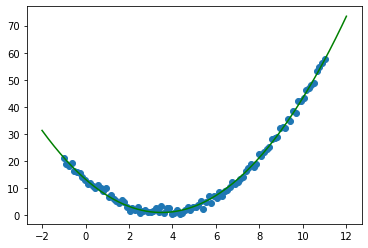

In [76]:
import numpy as np
import matplotlib.pyplot as plt
# PolynomialFeatures 多项式特征
from sklearn.preprocessing import PolynomialFeatures,StandardScaler # 标准化
from sklearn.linear_model import SGDRegressor # 梯度下降的线性回归

# 1、创建数据，并进行可视化
X = np.linspace(-1,11,num = 100)
y = (X - 5)**2 + 3*X -12 + np.random.randn(100)
X = X.reshape(-1,1)
plt.scatter(X,y)

# 2、创建预测数据
X_test = np.linspace(-2,12,num = 200).reshape(-1,1)
# 3、使用PolynomialFeatures进行特征升维
poly = PolynomialFeatures()
poly.fit(X,y)
X = poly.transform(X)
s = StandardScaler()
X = s.fit_transform(X) # 归一化
model = SGDRegressor(penalty='l2',eta0 = 0.01,max_iter=100000,learning_rate='constant')
model.fit(X,y)

# 4、预测数据
X_test = poly.transform(X_test)
X_test_norm = s.transform(X_test) # 对预测值，进行了归一化
y_test = model.predict(X_test_norm)
plt.plot(X_test[:,1],y_test,color = 'green')

In [59]:
X = np.random.randint(0,10,size = (5,2))
display(X)

array([[2, 8],
       [1, 5],
       [1, 6],
       [1, 0],
       [5, 9]])

In [61]:
poly = PolynomialFeatures(degree=2,interaction_only=True,include_bias=False)
poly.fit_transform(X)

array([[ 2.,  8., 16.],
       [ 1.,  5.,  5.],
       [ 1.,  6.,  6.],
       [ 1.,  0.,  0.],
       [ 5.,  9., 45.]])

In [62]:
poly = PolynomialFeatures(degree=2,interaction_only=False,include_bias=False)
poly.fit_transform(X)

array([[ 2.,  8.,  4., 16., 64.],
       [ 1.,  5.,  1.,  5., 25.],
       [ 1.,  6.,  1.,  6., 36.],
       [ 1.,  0.,  1.,  0.,  0.],
       [ 5.,  9., 25., 45., 81.]])